# Deep Learning — Week 3: PyTorch 입문

**Student Version**

---

## 이번 주 학습 목표
1. PyTorch Tensor가 NumPy 배열과 어떻게 다른지 설명할 수 있다
2. Autograd가 gradient를 자동으로 계산하는 원리를 이해한다
3. `nn.Module`, `loss`, `optimizer`를 사용해 학습 루프를 작성할 수 있다
4. 1·2주차 NumPy 코드를 PyTorch 코드로 변환할 수 있다

## 지난 2주와의 연결

> 1·2주차에서 우리는 모든 것을 **손으로** 계산했습니다.
> ```python
> # 매번 직접 계산해야 했던 것들
> dw = 2 * np.mean((y_pred - y) * x)   # gradient 수식 외워서
> w  = w - lr * dw                      # 직접 업데이트
> ```
> PyTorch는 이것을 **자동으로** 해줍니다.
> ```python
> loss.backward()      # gradient 자동 계산
> optimizer.step()     # 자동 업데이트
> ```
> 구조는 완전히 같습니다. 단지 손 계산이 자동화됩니다.

---
# Part 1. 강의 내용 (영상과 동일)

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

print('PyTorch version:', torch.__version__)
print('GPU available  :', torch.cuda.is_available())

PyTorch version: 2.10.0+cu128
GPU available  : True


---
## 1. Tensor — PyTorch의 기본 단위

### Tensor란?

NumPy 배열과 거의 동일하지만 두 가지 결정적인 차이가 있습니다.

| | NumPy array | PyTorch Tensor |
|---|---|---|
| GPU 사용 | ❌ | ✅ (`.to('cuda')`) |
| 자동 미분 | ❌ | ✅ (`requires_grad=True`) |
| 문법 | `np.array(...)` | `torch.tensor(...)` |

딥러닝에서 수백만 개의 파라미터를 학습할 때, **GPU**와 **자동 미분**이 없으면 현실적으로 불가능합니다.  
Tensor는 이 두 가지를 모두 지원합니다.

In [2]:
# ── Tensor 생성 ───────────────────────────────────────────
# NumPy와 문법이 거의 동일합니다
a = torch.tensor([1.0, 2.0, 3.0])
print('tensor:', a)
print('shape :', a.shape)    # torch.Size([3])
print('dtype :', a.dtype)    # torch.float32

# 자주 쓰는 생성 함수 (NumPy와 대응)
print('\ntorch.zeros(2,3):\n', torch.zeros(2, 3))
print('torch.ones(2,3):\n',  torch.ones(2, 3))
print('torch.randn(2,3):\n', torch.randn(2, 3))
print('torch.arange(0,5):', torch.arange(0, 5))

# NumPy 배열 → Tensor 변환
arr = np.array([1.0, 2.0, 3.0])
t   = torch.from_numpy(arr)
print('\nnumpy → tensor:', t)

# Tensor → NumPy 변환
print('tensor → numpy:', t.numpy())

tensor: tensor([1., 2., 3.])
shape : torch.Size([3])
dtype : torch.float32

torch.zeros(2,3):
 tensor([[0., 0., 0.],
        [0., 0., 0.]])
torch.ones(2,3):
 tensor([[1., 1., 1.],
        [1., 1., 1.]])
torch.randn(2,3):
 tensor([[ 0.5478,  0.6551,  0.3897],
        [ 0.1300, -0.7829,  0.4506]])
torch.arange(0,5): tensor([0, 1, 2, 3, 4])

numpy → tensor: tensor([1., 2., 3.], dtype=torch.float64)
tensor → numpy: [1. 2. 3.]


In [3]:
# ── Tensor 연산 — NumPy와 거의 동일 ──────────────────────
A = torch.tensor([[1.0, 2.0],
                   [3.0, 4.0]])
B = torch.tensor([[5.0, 6.0],
                   [7.0, 8.0]])

print('A + B:\n', A + B)             # 원소별 덧셈
print('A * B:\n', A * B)             # 원소별 곱셈
print('A @ B:\n', A @ B)             # 행렬 곱
print('A.T:\n',   A.T)               # 전치
print('A.sum():', A.sum())           # 전체 합
print('A.mean(dim=0):', A.mean(dim=0))  # axis=0 (NumPy의 axis와 동일)

# shape 변환 — reshape 대신 view 또는 reshape
c = torch.arange(12, dtype=torch.float32)
print('\noriginal:', c.shape)
print('view(3,4):', c.view(3, 4).shape)
print('reshape(2,-1):', c.reshape(2, -1).shape)

A + B:
 tensor([[ 6.,  8.],
        [10., 12.]])
A * B:
 tensor([[ 5., 12.],
        [21., 32.]])
A @ B:
 tensor([[19., 22.],
        [43., 50.]])
A.T:
 tensor([[1., 3.],
        [2., 4.]])
A.sum(): tensor(10.)
A.mean(dim=0): tensor([2., 3.])

original: torch.Size([12])
view(3,4): torch.Size([3, 4])
reshape(2,-1): torch.Size([2, 6])


In [4]:
# 참고: numpy의 reshape도 가능하면 메모리를 공유합니다. 불가피한 경우 복사
a=np.array([1,2,3,4])
print(a)
print('------')
b=a.reshape(2,2)
b[0,0]=100
print(a,"<-b를 바꿨지만 a도 변한다.")
print(b)

[1 2 3 4]
------
[100   2   3   4] <-b를 바꿨지만 a도 변한다.
[[100   2]
 [  3   4]]


---
## 2. Autograd — 자동 미분

### 핵심 아이디어

1·2주차에서 gradient를 수식으로 직접 유도하고 코딩했습니다.

$$\frac{\partial L}{\partial w} = \frac{2}{N} X^T(\hat{y} - y) \quad \leftarrow \text{직접 계산}$$

PyTorch는 **연산 과정을 기록**해두었다가, `loss.backward()`를 호출하면  
**chain rule(연쇄법칙)을 자동으로 적용**해서 모든 파라미터의 gradient를 계산합니다.

어떤 복잡한 모델이든, gradient를 손으로 유도할 필요가 없습니다.

### `requires_grad=True`

gradient를 추적하고 싶은 Tensor에 이 옵션을 붙입니다.  
학습할 파라미터(w, b)는 반드시 `requires_grad=True`여야 합니다.

In [5]:
# ── Autograd 기본 예제 ────────────────────────────────────
# 간단한 함수: L = (w*x - y)^2 의 gradient를 구해보자

x = torch.tensor(2.0)
y = torch.tensor(5.0)
w = torch.tensor(1.0, requires_grad = True)   # 학습할 파라미터 (미분 할 대상)

# Forward pass — 연산 기록 시작
y_pred = w * x
loss   = (y_pred - y) ** 2

print('y_pred:', y_pred.item())  #item(): 텐서에서 Python 스칼라 값을 추출하는 메서드. 원소가 1개인 텐서에서만 사용 가능
print('loss  :', loss.item())
print('w.grad (before backward):', w.grad)  # None, 초기이므로 이전 값이 없음.

# Backward pass — gradient 자동 계산
loss.backward()

print('w.grad (after backward) :', w.grad.item()) 
# 수식으로 확인: dL/dw = 2*(w*x - y)*x = 2*(2-5)*2 = -12
print('Manual check  : 2*(w*x - y)*x =', 2*(1*2 - 5)*2)

y_pred: 2.0
loss  : 9.0
w.grad (before backward): None
w.grad (after backward) : -12.0
Manual check  : 2*(w*x - y)*x = -12


In [6]:
# ── 주의사항: gradient 누적 ────────────────────────────────
# PyTorch는 기본적으로 gradient를 누적합니다
# 매 iteration마다 반드시 zero_grad()를 먼저 호출해야 합니다

w = torch.tensor(1.0, requires_grad=True)

for i in range(3):
    y_pred = w * x
    loss   = (y_pred - y) ** 2
    loss.backward()
    print(f'Step {i+1} — w.grad: {w.grad.item():.1f}  ← 누적되고 있음!')

print()
w = torch.tensor(1.0, requires_grad=True)
for i in range(3):
    if w.grad is not None:
        w.grad.zero_()          # ← 반드시 초기화
    y_pred = w * x
    loss   = (y_pred - y) ** 2
    loss.backward()
    print(f'Step {i+1} — w.grad: {w.grad.item():.1f}  ← 올바름')

Step 1 — w.grad: -12.0  ← 누적되고 있음!
Step 2 — w.grad: -24.0  ← 누적되고 있음!
Step 3 — w.grad: -36.0  ← 누적되고 있음!

Step 1 — w.grad: -12.0  ← 올바름
Step 2 — w.grad: -12.0  ← 올바름
Step 3 — w.grad: -12.0  ← 올바름


---
## 3. nn.Module — 신경망 레이어

### PyTorch로 선형회귀 모델 만들기

`nn.Linear(in_features, out_features)`는  
$\hat{y} = Xw^T + b$ 를 자동으로 처리해줍니다.

- **w, b를 직접 선언할 필요 없음** — 자동으로 생성, `requires_grad=True` 자동 설정
- **forward pass를 직접 구현할 필요 없음** — `model(X)` 한 줄로 처리

### Loss 함수와 Optimizer

| NumPy (직접 구현) | PyTorch (자동) |
|---|---|
| `loss = np.mean((y_pred-y)**2)` | `criterion = nn.MSELoss()` |
| `dw = 2*np.mean(...)` | `loss.backward()` |
| `w = w - lr * dw` | `optimizer.step()` |

In [7]:
# ── nn.Linear 이해하기 ────────────────────────────────────
# 입력 특성 1개 → 출력 1개 (단변수 선형회귀)
model = nn.Linear(in_features = 1, out_features = 1)

print('Model:', model)
print('\nParameters:')
for name, param in model.named_parameters(): 
    print(f'  {name}: shape = {param.shape}, requires_grad = {param.requires_grad}')
    print(f'    value = {param.data}')
 
# 예측 (forward pass)
x_sample = torch.tensor([[2.0], [3.0], [4.0]])   # (3, 1) 입력이 하나라도 2D로!
y_sample  = model(x_sample)                        # (3, 1) 출력도 2D!
print('\nPrediction shape:', y_sample.shape)
print('Predictions:', y_sample.detach()) # detach 함수는 해당 값에게 gradient 추적을 중단시켜 결과만 깔끔히 출력하게 해줌.

Model: Linear(in_features=1, out_features=1, bias=True)

Parameters:
  weight: shape = torch.Size([1, 1]), requires_grad = True
    value = tensor([[-0.2368]])
  bias: shape = torch.Size([1]), requires_grad = True
    value = tensor([0.4312])

Prediction shape: torch.Size([3, 1])
Predictions: tensor([[-0.0424],
        [-0.2792],
        [-0.5160]])


---
## 4. PyTorch 학습 루프 — 1주차 선형회귀 재구현

### NumPy 코드 vs PyTorch 코드 비교

```python
# ── NumPy (1주차) ──────────────────  # ── PyTorch (이번 주) ──────────────
w, b = 0.0, 0.0                         model = nn.Linear(1, 1) #입력 1개, 츨력 1개. Y = w*X + b
                                        optimizer = torch.optim.SGD(
                                            model.parameters(), lr=0.01)
                                        criterion = nn.MSELoss()

for epoch in range(epochs):             for epoch in range(epochs):
    y_pred = w * x + b                      optimizer.zero_grad()       # ← 추가
    loss = np.mean((y_pred-y)**2)           y_pred = model(X)
    dw = 2*np.mean((y_pred-y)*x)            loss = criterion(y_pred, y)
    db = 2*np.mean(y_pred-y)                loss.backward()             # ← 자동
    w -= lr * dw                            optimizer.step()            # ← 자동
    b -= lr * db
```

**달라진 것**: `zero_grad()` + `backward()` + `step()` 세 줄이 수동 gradient 계산을 대체합니다.  
**동일한 것**: Forward → Loss → Update 라는 **구조**는 완전히 같습니다.

In [8]:
# ── 데이터 준비 ───────────────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)

N = 60
x_np = np.random.uniform(0, 10, N).astype(np.float32)
y_np = (2.5 * x_np + 1.0 + np.random.randn(N) * 2).astype(np.float32)

# NumPy → Tensor 변환
X = torch.from_numpy(x_np).reshape(-1, 1)   # (60, 1)
y = torch.from_numpy(y_np).reshape(-1, 1)   # (60, 1)

print('X shape:', X.shape, '| dtype:', X.dtype)
print('y shape:', y.shape, '| dtype:', y.dtype)

# ── 모델, Loss, Optimizer ────────────────────────────────
torch.manual_seed(0)
model     = nn.Linear(1, 1)                          # y = wx + b
criterion = nn.MSELoss()                              # MSE Loss
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)  # SGD는 gradient의 일종임. Stochastic Gradient Descent (확률적 경사하강법)

# ── 학습 루프 ─────────────────────────────────────────────
epochs = 300
loss_history = [] # 비어있는 리스트 추가

for epoch in range(epochs):

    # 0) Gradient 초기화 (반드시 매 iteration 맨 처음)
    optimizer.zero_grad() ## <- 중요!

    # 1) Forward pass
    y_pred = model(X)

    # 2) Loss
    loss = criterion(y_pred, y)
    loss_history.append(loss.item()) # 매 epooch마다 append.

    # 3) Backward — gradient 자동 계산
    loss.backward()

    # 4) Update — optimizer가 파라미터 업데이트
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        w_val = model.weight.item()
        b_val = model.bias.item()
        print(f'Epoch {epoch+1:3d} | Loss: {loss.item():.4f} | w: {w_val:.4f} | b: {b_val:.4f}')

print(f'\nLearned: w={model.weight.item():.4f}, b={model.bias.item():.4f}')
print(f'True   : w=2.5000, b=1.0000')

X shape: torch.Size([60, 1]) | dtype: torch.float32
y shape: torch.Size([60, 1]) | dtype: torch.float32
Epoch 100 | Loss: 3.1051 | w: 2.4482 | b: 1.0291
Epoch 200 | Loss: 3.1006 | w: 2.4382 | b: 1.0943
Epoch 300 | Loss: 3.0992 | w: 2.4327 | b: 1.1308

Learned: w=2.4327, b=1.1308
True   : w=2.5000, b=1.0000


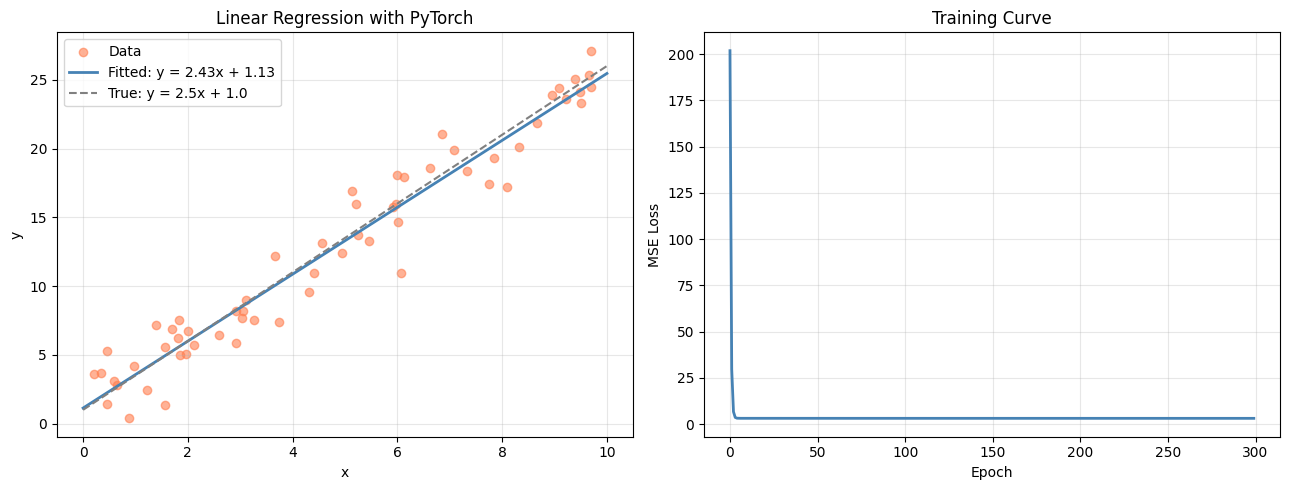

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: fitted line
x_line = np.linspace(0, 10, 100).astype(np.float32)

with torch.no_grad():   # gradient 추적 불필요한 구간
    y_line = model(torch.from_numpy(x_line).reshape(-1, 1)).numpy() #tensor를 numpy로 변환

axes[0].scatter(x_np, y_np, color='coral', alpha=0.6, label='Data')
axes[0].plot(x_line, y_line, color='steelblue', linewidth=2,
             label=f'Fitted: y = {model.weight.item():.2f}x + {model.bias.item():.2f}')
axes[0].plot(x_line, 2.5*x_line + 1.0, color='gray', linestyle='--',
             linewidth=1.5, label='True: y = 2.5x + 1.0')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')
axes[0].set_title('Linear Regression with PyTorch')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Right: loss curve
axes[1].plot(loss_history, color='steelblue', linewidth=2)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MSE Loss')
axes[1].set_title('Training Curve')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 5. PyTorch 학습 루프 — 2주차 로지스틱 회귀 재구현

이제 같은 패턴으로 로지스틱 회귀도 PyTorch로 옮겨봅니다.  
바뀌는 것은 **모델 구조**와 **Loss 함수** 두 가지뿐입니다.

### 모델 구조

```python
# NumPy (2주차): sigmoid를 직접 구현
y_pred = 1 / (1 + np.exp(-(X @ w + b)))

# PyTorch: nn.Sequential로 레이어를 쌓음
model = nn.Sequential(
    nn.Linear(2, 1),   # Xw + b
    nn.Sigmoid()       # sigmoid 적용
)
```

### Loss 함수

```python
criterion = nn.BCELoss()   # Binary Cross-Entropy
```

In [10]:
# ── 데이터 (2주차와 동일) ─────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)
N = 100
X0 = np.random.randn(N//2, 2) + np.array([-1.5, -1.5])
X1 = np.random.randn(N//2, 2) + np.array([ 1.5,  1.5])
X_np = np.vstack([X0, X1]).astype(np.float32)
y_np = np.array([0]*50 + [1]*50).astype(np.float32)

# 정규화 후 Tensor 변환
X_mean, X_std = X_np.mean(0), X_np.std(0)
X_norm_np = ((X_np - X_mean) / X_std).astype(np.float32)

X_t = torch.from_numpy(X_norm_np)          # (100, 2)
y_t = torch.from_numpy(y_np).reshape(-1, 1) # (100, 1)

# ── 모델 정의 ─────────────────────────────────────────────
torch.manual_seed(0)
model_cls = nn.Sequential(
    nn.Linear(2, 1),   # 입력 특성 2개 → 출력 1개
    nn.Sigmoid()       # 확률값으로 변환
)

criterion_cls = nn.BCELoss()
optimizer_cls = torch.optim.SGD(model_cls.parameters(), lr=0.1)

print('Model structure:')
print(model_cls)
print('\nTotal parameters:', sum(p.numel() for p in model_cls.parameters()))

Model structure:
Sequential(
  (0): Linear(in_features=2, out_features=1, bias=True)
  (1): Sigmoid()
)

Total parameters: 3


In [11]:
# ── 학습 루프 — 구조가 선형회귀와 완전히 동일 ────────────
epochs = 300
loss_hist_cls = []
acc_hist_cls  = []

for epoch in range(epochs):

    optimizer_cls.zero_grad()           # 0) gradient 초기화
    y_pred_cls = model_cls(X_t)         # 1) Forward
    loss_cls   = criterion_cls(y_pred_cls, y_t)  # 2) Loss
    loss_cls.backward()                 # 3) Backward
    optimizer_cls.step()                # 4) Update

    # Accuracy 계산
    with torch.no_grad():
        preds = (y_pred_cls >= 0.5).float()
        acc   = (preds == y_t).float().mean().item() 

    loss_hist_cls.append(loss_cls.item()) 
    acc_hist_cls.append(acc)

    if (epoch + 1) % 100 == 0:
        print(f'Epoch {epoch+1:3d} | Loss: {loss_cls.item():.4f} | Accuracy: {acc*100:.1f}%')

print(f'\nFinal Accuracy: {acc_hist_cls[-1]*100:.1f}%')

Epoch 100 | Loss: 0.1189 | Accuracy: 100.0%
Epoch 200 | Loss: 0.0775 | Accuracy: 100.0%
Epoch 300 | Loss: 0.0606 | Accuracy: 100.0%

Final Accuracy: 100.0%


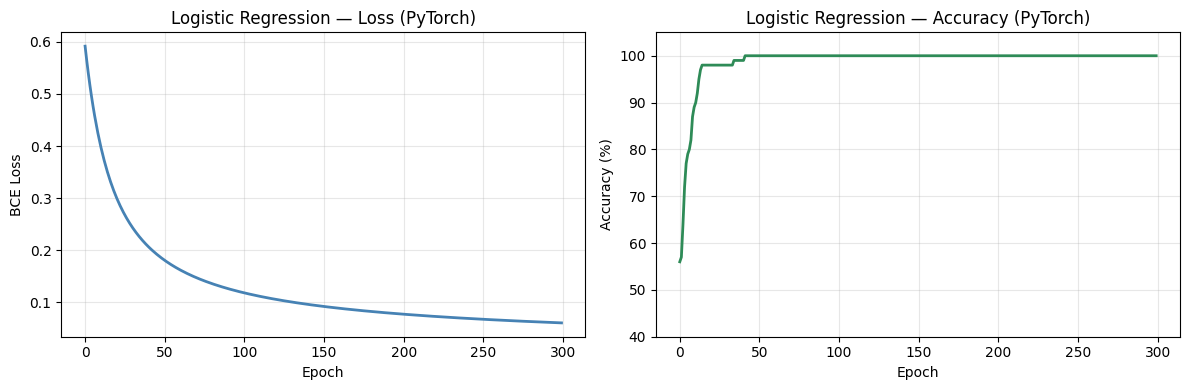

In [12]:
# 학습 곡선
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(loss_hist_cls, color='steelblue', linewidth=2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')
axes[0].set_title('Logistic Regression — Loss (PyTorch)')
axes[0].grid(True, alpha=0.3)

axes[1].plot([a*100 for a in acc_hist_cls], color='seagreen', linewidth=2)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Logistic Regression — Accuracy (PyTorch)')
axes[1].set_ylim(40, 105)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 6. Dataset & DataLoader

### 왜 필요한가?

지금까지는 전체 데이터를 한 번에 모델에 넣었습니다 (batch = 전체).  
실제 딥러닝에서는 **미니배치(mini-batch)** 로 나눠서 학습합니다.

| 방식 | 설명 | 장단점 |
|---|---|---|
| Batch GD | 전체 데이터를 한 번에 | 안정적, 느림, 메모리 큼 |
| Mini-batch GD | N개씩 나눠서 | **실제 딥러닝의 표준** |
| Stochastic GD | 1개씩 | 빠르지만 불안정 |

PyTorch는 `Dataset`과 `DataLoader`로 미니배치 처리를 자동화합니다.

```python
dataset    = TensorDataset(X, y)           # 데이터 묶기
dataloader = DataLoader(dataset,
                        batch_size=32,     # 한 번에 32개씩
                        shuffle=True)      # 매 epoch마다 섞기
```

In [13]:
from torch.utils.data import TensorDataset, DataLoader

# ── Dataset & DataLoader 생성 ─────────────────────────────
dataset    = TensorDataset(X_t, y_t)          # X와 y를 묶기
dataloader = DataLoader(dataset, batch_size = 32, shuffle = True)

print(f'Total samples  : {len(dataset)}')
print(f'Batch size     : 32')
print(f'Batches/epoch  : {len(dataloader)}')
print()

# 한 배치 확인
X_batch, y_batch = next(iter(dataloader))
print(f'X_batch shape: {X_batch.shape}')   # (32, 2)
print(f'y_batch shape: {y_batch.shape}')   # (32, 1)

Total samples  : 100
Batch size     : 32
Batches/epoch  : 4

X_batch shape: torch.Size([32, 2])
y_batch shape: torch.Size([32, 1])


Epoch 10 | Loss: 0.2247
Epoch 20 | Loss: 0.1154
Epoch 30 | Loss: 0.1164


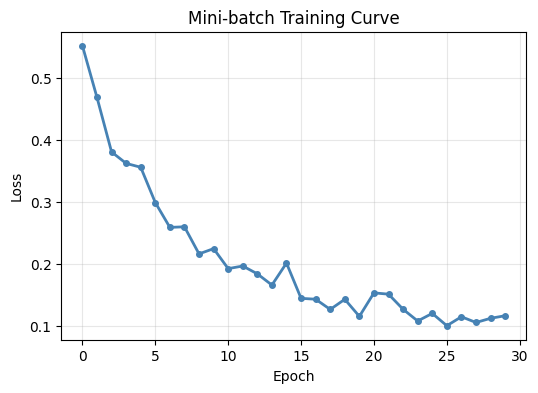

In [14]:
# ── 미니배치 학습 루프 ────────────────────────────────────
torch.manual_seed(0)
model_mb     = nn.Sequential(nn.Linear(2, 1), nn.Sigmoid())
criterion_mb = nn.BCELoss()
optimizer_mb = torch.optim.SGD(model_mb.parameters(), lr=0.1)

epochs = 30
epoch_losses = []

for epoch in range(epochs):
    batch_losses = []

    for X_batch, y_batch in dataloader:      # ← 미니배치 순회
        optimizer_mb.zero_grad()
        y_pred_mb = model_mb(X_batch)
        loss_mb   = criterion_mb(y_pred_mb, y_batch)
        loss_mb.backward()
        optimizer_mb.step()
        batch_losses.append(loss_mb.item())

    epoch_loss = np.mean(batch_losses)       # 한 epoch 평균 loss
    epoch_losses.append(epoch_loss)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:2d} | Loss: {epoch_loss:.4f}')

plt.figure(figsize=(6, 4))
plt.plot(epoch_losses, color='steelblue', linewidth=2, marker='o', markersize=4)
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Mini-batch Training Curve')
plt.grid(True, alpha=0.3)
plt.show()

---
## 7. 커스텀 모델 — nn.Module 상속

`nn.Sequential`은 간단하지만, 복잡한 모델(ResNet, Transformer 등)은  
`nn.Module`을 상속해서 직접 클래스를 만듭니다.  
앞으로 계속 이 패턴을 쓸 것이므로 기본 구조를 익혀둡니다.

```python
class MyModel(nn.Module):
    def __init__(self):
        super().__init__()
        # 레이어 정의

    def forward(self, x):
        # 데이터 흐름 정의
        return x
```

- `__init__`: 레이어(파라미터) 선언
- `forward`: 데이터가 어떻게 흐르는지 정의 (= forward pass)
- `backward`: **직접 구현하지 않아도 됨** — autograd가 자동으로 처리

In [15]:
# ── 커스텀 로지스틱 회귀 모델 ──────────────────────────────
class LogisticRegression(nn.Module):

    def __init__(self, n_features):
        super().__init__()
        self.linear = nn.Linear(n_features, 1)   # 레이어 선언
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        z = self.linear(x)     # linear layer 통과
        return self.sigmoid(z) # sigmoid 적용


# 사용법은 완전히 동일
torch.manual_seed(0)
model_custom = LogisticRegression(n_features=2)
optimizer_custom = torch.optim.SGD(model_custom.parameters(), lr=0.1)
criterion_custom = nn.BCELoss()

print('Model:', model_custom)
print()

# 학습
for epoch in range(300):
    optimizer_custom.zero_grad()
    y_pred_c = model_custom(X_t)
    loss_c   = criterion_custom(y_pred_c, y_t)
    loss_c.backward()
    optimizer_custom.step()

with torch.no_grad():
    preds_c = (model_custom(X_t) >= 0.5).float()
    acc_c   = (preds_c == y_t).float().mean().item()
print(f'Final Accuracy: {acc_c*100:.1f}%')

# 모델 저장 / 불러오기 맛보기
torch.save(model_custom.state_dict(), '/tmp/logistic_model.pth')
print('Model saved!')

model_loaded = LogisticRegression(n_features=2)
model_loaded.load_state_dict(torch.load('/tmp/logistic_model.pth'))
model_loaded.eval()
print('Model loaded!')

Model: LogisticRegression(
  (linear): Linear(in_features=2, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

Final Accuracy: 100.0%
Model saved!
Model loaded!


### 3주차 핵심 정리

**PyTorch 학습 루프 5단계 — 앞으로 항상 이 구조입니다**

```python
for epoch in range(epochs):
    optimizer.zero_grad()          # 0) gradient 초기화 (필수!)
    y_pred = model(X)              # 1) Forward pass
    loss   = criterion(y_pred, y)  # 2) Loss 계산
    loss.backward()                # 3) Backward (gradient 자동 계산)
    optimizer.step()               # 4) 파라미터 업데이트
```

**앞으로 바뀌는 것**

| 주차 | 바뀌는 것 | 바뀌지 않는 것 |
|---|---|---|
| 4주차 | 모델에 은닉층 추가, 활성화 함수 | 학습 루프 5단계 |
| 5주차 | 더 깊은 모델, BatchNorm | 학습 루프 5단계 |
| 9주차 | 모델이 CNN으로 교체 | 학습 루프 5단계 |

**학습 루프 구조는 이번 주부터 강좌 끝까지 변하지 않습니다.**

### 다음 주 예고
> 단층 모델(로지스틱 회귀)에 **은닉층**을 추가합니다.  
> XOR 문제를 선형 모델은 못 풀었는데 — 은닉층을 추가하면 풀 수 있을까요?


---
---

# Part 2. 실습 문제

> **[A] 한 줄 채우기** — 8문제  
> **[B] 여러 줄 채우기** — 2문제 (힌트 제공)
>
> - `______` 로 표시된 부분만 채우세요
> - 막히면 위 Part 1의 같은 개념 코드를 참고하세요
> - [B] 문제 중 못 한 것은 숙제입니다

---
## [A] 한 줄 채우기

In [16]:
import torch
import torch.nn as nn
import numpy as np

# ─────────────────────────────────────────────
# A-1. NumPy 배열을 Tensor로 변환
# Expected: tensor([1., 2., 3.])  dtype=torch.float32
# ─────────────────────────────────────────────
arr = np.array([1.0, 2.0, 3.0])
t   = torch.from_numpy(arr) # 반대의 경우일 시 t.numpy() 함수
print('tensor:', t, '| dtype:', t.dtype)

tensor: tensor([1., 2., 3.], dtype=torch.float64) | dtype: torch.float64


In [17]:
# ─────────────────────────────────────────────
# A-2. requires_grad 설정
# w는 학습할 파라미터 — gradient 추적이 필요합니다
# Expected: requires_grad=True
# ─────────────────────────────────────────────
w = torch.tensor(1.0, requires_grad = True)
print('requires_grad:', w.requires_grad)

requires_grad: True


In [18]:
# ─────────────────────────────────────────────
# A-3. Backward 호출 — gradient 계산
# loss = w^2 일 때 dL/dw = 2w = 6.0
# Expected: w.grad = 6.0
# ─────────────────────────────────────────────
w    = torch.tensor(3.0, requires_grad=True)
loss = w ** 2
loss.backward()          # gradient 계산
print('w.grad:', w.grad.item())   # 6.0

w.grad: 6.0


In [19]:
# ─────────────────────────────────────────────
# A-4. 선형 레이어 정의
# 입력 특성 3개 → 출력 1개
# Expected: Linear(in_features=3, out_features=1, bias=True)
# ─────────────────────────────────────────────
layer = nn.Linear(3,1)
print(layer)

Linear(in_features=3, out_features=1, bias=True)


In [20]:
# ─────────────────────────────────────────────
# A-5. nn.Sequential로 로지스틱 회귀 모델 정의
# Linear(2→1) → Sigmoid
# ─────────────────────────────────────────────
model = nn.Sequential(
    nn.Linear(2, 1),
    nn.Sigmoid()
)
print(model)

Sequential(
  (0): Linear(in_features=2, out_features=1, bias=True)
  (1): Sigmoid()
)


In [21]:
# ─────────────────────────────────────────────
# A-6. SGD Optimizer 정의
# learning rate = 0.01
# ─────────────────────────────────────────────
optimizer = torch.optim.SGD(model.parameters(), lr=0.01) # 복잡하니 여러번 코드 확인하기 (torch.optim)
print(optimizer)

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)


In [22]:
# ─────────────────────────────────────────────
# A-7. DataLoader 생성
# batch_size=16, shuffle=True
# ─────────────────────────────────────────────
from torch.utils.data import TensorDataset, DataLoader

X_t = torch.randn(100, 2)
y_t = torch.randint(0, 2, (100, 1)).float()

dataset    = TensorDataset(X_t, y_t)
dataloader = DataLoader(dataset, batch_size = 16, shuffle = True)

print('Batches per epoch:', len(dataloader))   # 100/16 → 7 (마지막 배치 포함)

Batches per epoch: 7


In [23]:
# ─────────────────────────────────────────────
# A-8. torch.no_grad() 블록에서 accuracy 계산
# gradient 계산이 필요 없는 evaluation 구간
# ─────────────────────────────────────────────
torch.manual_seed(0)
model_test = nn.Sequential(nn.Linear(2, 1), nn.Sigmoid())

with torch.no_grad() :   # gradient 추적 비활성화
    y_pred_test = model_test(X_t)
    preds = (y_pred_test >= 0.5).float()
    acc   = (preds == y_t).float().mean().item()
print(f'Accuracy: {acc*100:.1f}%')

Accuracy: 43.0%


---
## [B] 여러 줄 채우기

Learned: w=1.6859, b=2.1142
True   : w=1.5000, b=3.0000


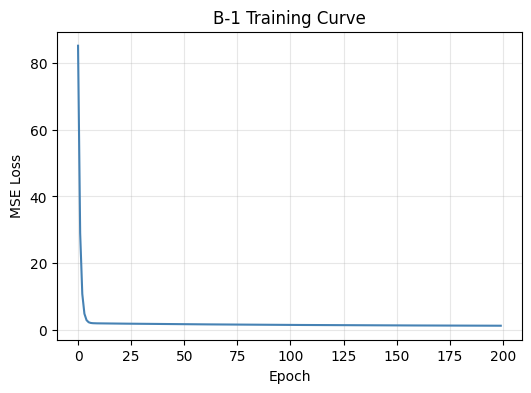

In [24]:
# ─────────────────────────────────────────────
# B-1. PyTorch로 선형회귀 학습 루프 완성
#
# Hint:
#   5단계: zero_grad() → forward → loss → backward() → step()
#   model.weight.item(), model.bias.item() 으로 파라미터 확인
# ─────────────────────────────────────────────
torch.manual_seed(42)
np.random.seed(7)
N = 50
x_np = np.random.uniform(0, 8, N).astype(np.float32)
y_np = (1.5 * x_np + 3.0 + np.random.randn(N)).astype(np.float32)

X_b1 = torch.from_numpy(x_np).reshape(-1, 1)
y_b1 = torch.from_numpy(y_np).reshape(-1, 1)

torch.manual_seed(0)
model_b1     = nn.Linear(1, 1)
criterion_b1 = nn.MSELoss()
optimizer_b1 = torch.optim.SGD(model_b1.parameters(), lr=0.01)

loss_hist_b1 = []

for epoch in range(200):

    # 0) Gradient 초기화
    optimizer_b1.zero_grad()       

    # 1) Forward
    y_pred_b1 = model_b1(X_b1)

    # 2) Loss
    loss_b1 = criterion_b1(y_b1, y_pred_b1)
    loss_hist_b1.append(loss_b1.item())

    # 3) Backward
    loss_b1.backward()

    # 4) Update
    optimizer_b1.step()
#   model.weight.item(), model.bias.item() 으로 파라미터 확인
print(f'Learned: w={model_b1.weight.item():.4f}, b={model_b1.bias.item():.4f}') 
print(f'True   : w=1.5000, b=3.0000')

plt.figure(figsize=(6, 4))
plt.plot(loss_hist_b1, color='steelblue')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.title('B-1 Training Curve')
plt.grid(True, alpha=0.3)
plt.show()

## 도전문제를 시도하고 싶은 학생만 해보세요! (선택사항, 학습 범위 제외)

Final Loss    : 0.0606
Final Accuracy: 100.0%


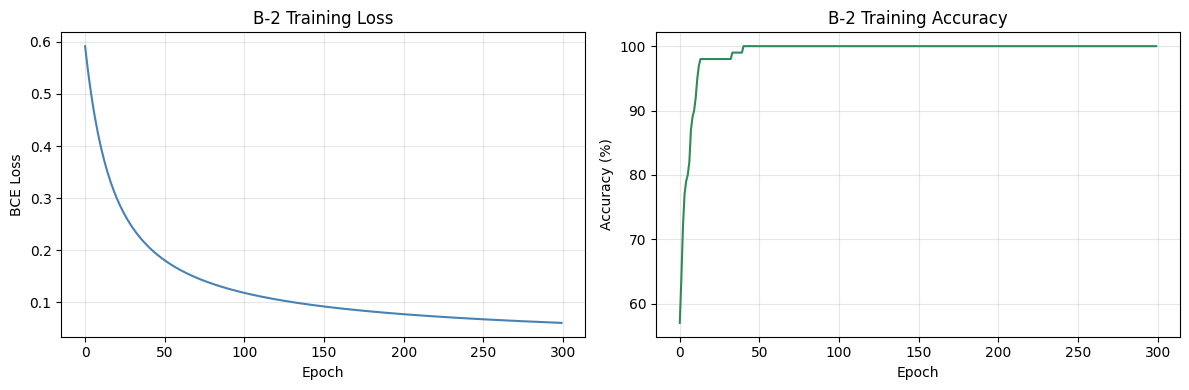

In [27]:
# ─────────────────────────────────────────────
# B-2. nn.Module 상속으로 커스텀 로지스틱 회귀 구현
#
# Hint:
#   class 구조:
#     def __init__(self, n_features): → self.linear, self.sigmoid 선언
#     def forward(self, x):          → linear → sigmoid 순서
#
#   학습 루프는 B-1과 동일한 5단계
#   Loss: nn.BCELoss()
# ─────────────────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)
N = 100
X0 = np.random.randn(N//2, 2) + np.array([-1.5, -1.5])
X1 = np.random.randn(N//2, 2) + np.array([ 1.5,  1.5])
X_np_b2 = np.vstack([X0, X1]).astype(np.float32)
y_np_b2 = np.array([0]*50 + [1]*50).astype(np.float32)

X_mean_b2, X_std_b2 = X_np_b2.mean(0), X_np_b2.std(0)
X_b2 = torch.from_numpy(((X_np_b2 - X_mean_b2) / X_std_b2).astype(np.float32))
y_b2 = torch.from_numpy(y_np_b2).reshape(-1, 1)

# 커스텀 모델 클래스 정의
class LogisticRegression(nn.Module):

    def __init__(self, n_features):
        super().__init__()
        self.linear  = nn.Linear(n_features, 1)   # Linear layer
        self.sigmoid = nn.Sigmoid()   # Sigmoid activation

    def forward(self, x):
        z = self.linear(x)              # linear 통과
        return self.sigmoid(z)           # sigmoid 통과


torch.manual_seed(0)
model_b2     = LogisticRegression(n_features=2)
criterion_b2 = nn.BCELoss()
optimizer_b2 = torch.optim.SGD(model_b2.parameters(), lr=0.1)

loss_hist_b2 = []
acc_hist_b2  = []

for epoch in range(300):
    optimizer_b2.zero_grad()                                 # 0) zero_grad
    y_pred_b2 = model_b2(X_b2)                               # 1) forward
    loss_b2   = criterion_b2(y_pred_b2, y_b2)                # 2) loss
    loss_hist_b2.append(loss_b2.item())
    loss_b2.backward()                               # 3) backward
    optimizer_b2.step()                               # 4) update

    with torch.no_grad():
        preds = (model_b2(X_b2) >= 0.5).float()
        acc_hist_b2.append((preds == y_b2).float().mean().item())

print(f'Final Loss    : {loss_hist_b2[-1]:.4f}')
print(f'Final Accuracy: {acc_hist_b2[-1]*100:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(loss_hist_b2, color='steelblue')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')
axes[0].set_title('B-2 Training Loss'); axes[0].grid(True, alpha=0.3)
axes[1].plot([a*100 for a in acc_hist_b2], color='seagreen')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('B-2 Training Accuracy'); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
## Checklist

**[A] 한 줄 채우기**
- [ ] A-1. NumPy → Tensor 변환
- [ ] A-2. requires_grad 설정
- [ ] A-3. backward() 호출
- [ ] A-4. nn.Linear 정의
- [ ] A-5. nn.Sequential 모델
- [ ] A-6. SGD Optimizer
- [ ] A-7. DataLoader 생성
- [ ] A-8. torch.no_grad() 블록

**[B] 여러 줄 채우기**
- [ ] B-1. PyTorch 선형회귀 루프 완성
- [ ] B-2. nn.Module 커스텀 모델 구현 ← 도전 문제! (선택사항)

---
## 생각해볼 질문

1. `optimizer.zero_grad()`를 호출하지 않으면 어떻게 되나요? 직접 빼고 실행해보세요.
2. `torch.no_grad()` 블록이 왜 필요한가요? 없으면 어떤 문제가 생기나요?
3. B-1의 PyTorch 코드와 1주차 NumPy 코드를 나란히 놓고 **달라진 줄이 몇 줄인지** 세어보세요.